# Lumpyspace: Live Training Monitor
This notebook provides real-time visualization of the PINN training progress by reading the live CSV logs generated by `src/training/run.py`.

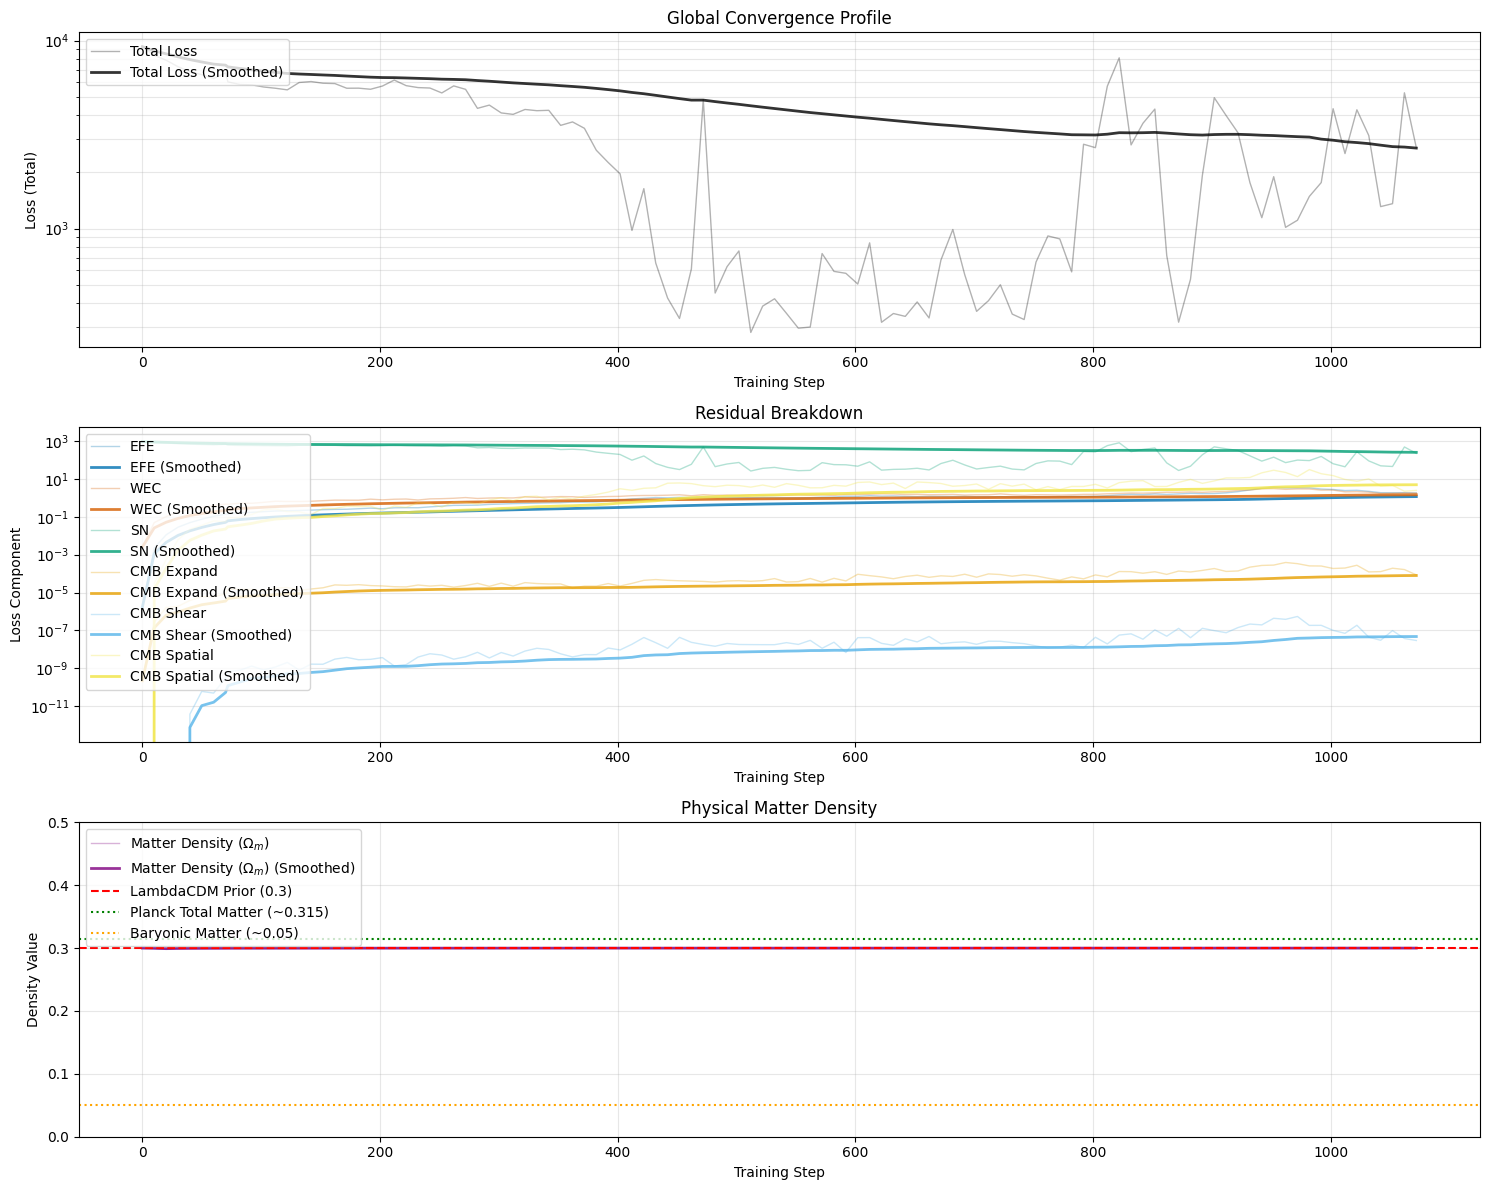

| last update  | 12:51:35     |
| step         | 1072         |
| loss         | 2.695e+03    |
| l_phys       | 1.791e+00    |
| l_sn         | 2.228e+02    |
| l_wec        | 1.783e+00    |
| l_expand     | 8.575e-05    |
| l_shear      | 2.940e-08    |
| l_spatial    | 2.476e+00    |
| Ω_m          | 3.000e-01    |


In [6]:
import os
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import clear_output

sys.path.append("..")
from src.training.loss import (
  METRIC_EXPAND,
  METRIC_LOSS,
  METRIC_OMEGA_M,
  METRIC_PHYS,
  METRIC_SHEAR,
  METRIC_SN,
  METRIC_SPATIAL,
  METRIC_WEC,
)

# Path to the production logs
log_path = "../logs/training_metrics.csv"

# Okabe-Ito Color Palette
color_efe = "#0072B2"  # Blue
color_wec = "#D55E00"  # Vermilion
color_sn = "#009E73"  # Bluish Green
color_bao = "#CC79A7"  # Reddish Purple
color_expand = "#E69F00"  # Orange
color_shear = "#56B4E9"  # Sky Blue
color_spatial = "#F0E442"  # Yellow


def plot_with_smoothing(ax, df_x, df_y, label, color):
  ax.plot(
    df_x,
    df_y.astype(float),
    label=label,
    color=color,
    linewidth=1,
    alpha=0.3,
  )
  ax.plot(
    df_x,
    df_y.astype(float).rolling(window=100, min_periods=1).mean(),
    label=f"{label} (Smoothed)",
    color=color,
    linewidth=2,
    alpha=0.8,
  )


def monitor_convergence():
  while True:
    if not os.path.exists(log_path):
      clear_output(wait=True)
      print(f"Waiting for log file: {log_path}...")
      time.sleep(5)
      continue

    try:
      df = pd.read_csv(log_path)
      if len(df) > 1:
        df = df[df["step"] > df["step"].max() - 10000]
        clear_output(wait=True)
        fig, ax = plt.subplots(3, 1, figsize=(15, 12))

        # Plot Total Loss (Log Scale)
        plot_with_smoothing(
          ax[0], df["step"], df[METRIC_LOSS], "Total Loss", "black"
        )
        ax[0].set_yscale("log")
        ax[0].set_xlabel("Training Step")
        ax[0].set_ylabel("Loss (Total)")
        ax[0].set_title("Global Convergence Profile")
        ax[0].grid(True, which="both", ls="-", alpha=0.3)
        ax[0].legend(loc="upper left")

        # Plot Components
        plot_with_smoothing(
          ax[1], df["step"], df[METRIC_PHYS], "EFE", color_efe
        )
        plot_with_smoothing(ax[1], df["step"], df[METRIC_WEC], "WEC", color_wec)
        plot_with_smoothing(ax[1], df["step"], df[METRIC_SN], "SN", color_sn)
        plot_with_smoothing(
          ax[1], df["step"], df[METRIC_EXPAND], "CMB Expand", color_expand
        )
        plot_with_smoothing(
          ax[1], df["step"], df[METRIC_SHEAR], "CMB Shear", color_shear
        )
        plot_with_smoothing(
          ax[1], df["step"], df[METRIC_SPATIAL], "CMB Spatial", color_spatial
        )
        # plot_with_smoothing(ax[1], df["step"], df[METRIC_BAO], "BAO", color_bao)

        ax[1].set_yscale("log")
        ax[1].set_xlabel("Training Step")
        ax[1].set_ylabel("Loss Component")
        ax[1].set_title("Residual Breakdown")
        ax[1].grid(True, which="both", ls="-", alpha=0.3)
        ax[1].legend(loc="upper left")

        # Plot Physical Matter Density
        plot_with_smoothing(
          ax[2],
          df["step"],
          df[METRIC_OMEGA_M],
          label="Matter Density ($\\Omega_m$)",
          color="purple",
        )
        ax[2].axhline(
          y=0.3, color="r", linestyle="--", label="LambdaCDM Prior (0.3)"
        )
        ax[2].axhline(
          y=0.315,
          color="green",
          linestyle=":",
          label="Planck Total Matter (~0.315)",
        )
        ax[2].axhline(
          y=0.05, color="orange", linestyle=":", label="Baryonic Matter (~0.05)"
        )
        ax[2].set_xlabel("Training Step")
        ax[2].set_ylabel("Density Value")
        ax[2].set_title("Physical Matter Density")
        # Constrain the chart to the physical realm, more or less.
        ax[2].set_ylim(0.0, 0.5)
        ax[2].grid(True, which="both", ls="-", alpha=0.3)
        ax[2].legend(loc="upper left")

        plt.tight_layout()
        plt.show()

        print(f"| {'last update':<12} | {time.strftime('%H:%M:%S'):<12} |")
        print(f"| {'step':<12} | {df['step'].iloc[-1]:<12} |")

        for metric in [
          METRIC_LOSS,
          METRIC_PHYS,
          METRIC_SN,
          METRIC_WEC,
          METRIC_EXPAND,
          METRIC_SHEAR,
          METRIC_SPATIAL,
        ]:
          print(f"| {metric:<12} | {df[metric].iloc[-1]:<12.3e} |")

        print(f"| {'\u03a9_m':<12} | {df[METRIC_OMEGA_M].iloc[-1]:<12.3e} |")

        # Plot once and return
        return
    except Exception as e:
      print(f"Error reading logs: {e}")

    time.sleep(10)  # Refresh every 10 seconds to reduce IO overhead


monitor_convergence()

## H and Shear plots

E0615 12:51:42.105288 1276079 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)
E0615 12:51:42.113236 1272799 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)


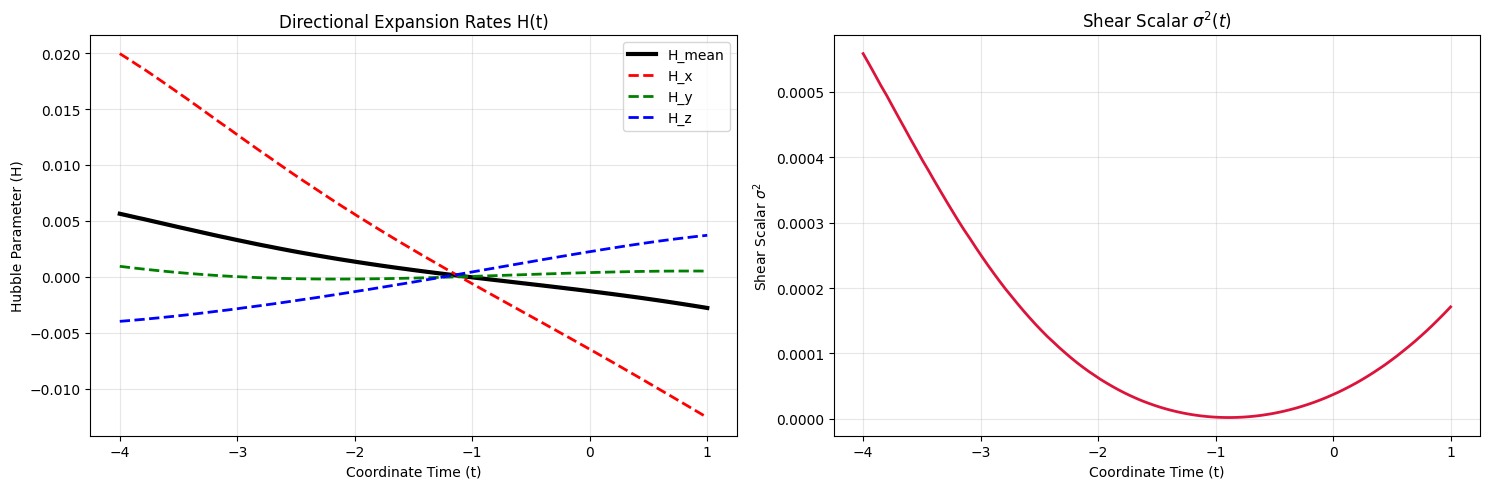

In [7]:
import sys

import equinox as eqx
import jax
import jax.numpy as jnp
from jax import jacfwd, vmap

# Ensure notebook can find the src module
sys.path.append(os.path.abspath('..'))

from src.core.metric import MetricNN

# 1. Load the checkpoint
checkpoint_path = "../checkpoints/pinn_metric.eqx"
key = jax.random.PRNGKey(0)
model_skeleton = MetricNN(key) # Blank structure
# Hydrate the model with your trained weights
model = eqx.tree_deserialise_leaves(checkpoint_path, model_skeleton)

# 2. The Extraction Math
def extract_cosmology(model, t_eval):
    def compute_kinematics(t):
        coords = jnp.array([t, 0.0, 0.0, 0.0])
        g = model(coords)
        
        # Spatial Metric
        g_spatial = g[1:4, 1:4]
        g_spatial_inv = jnp.linalg.inv(g_spatial)
        
        # d/dt g_ij (Derivative wrt coordinate time)
        dg_dt = jacfwd(model)(coords)[:, :, 0]
        dg_spatial_dt = dg_dt[1:4, 1:4]
        
        # Lapse function alpha
        alpha = jnp.sqrt(-g[0, 0])
        
        # Expansion & Hubble Tensors
        theta_ij = (1.0 / (2.0 * alpha)) * dg_spatial_dt
        h_tensor = jnp.einsum('ik,kj->ij', g_spatial_inv, theta_ij)
        
        h_mean = jnp.trace(h_tensor) / 3.0
        
        # Extract the directional expansion rates
        h_x, h_y, h_z = h_tensor[0,0], h_tensor[1,1], h_tensor[2,2]
        
        # Shear Tensor and Scalar
        sigma_tensor = h_tensor - h_mean * jnp.eye(3)
        sigma_sq = 0.5 * jnp.einsum('ij,ji->', sigma_tensor, sigma_tensor)
        
        return h_mean, sigma_sq, h_x, h_y, h_z
        
    return vmap(compute_kinematics)(t_eval)

# 3. Evaluate and Plot
t_eval = jnp.linspace(-4.0, 1.0, 100)

# Unpack all 5 variables
h_mean, sigma_sq, h_x, h_y, h_z = extract_cosmology(model, t_eval)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# --- LEFT CHART: Directional Expansion Rates ---
# Plot the mean as a solid thick black line
ax1.plot(t_eval, h_mean, color='black', linewidth=3, label='H_mean')

# Plot the directional components as dashed colored lines
ax1.plot(t_eval, h_x, color='red', linestyle='--', linewidth=2, label='H_x')
ax1.plot(t_eval, h_y, color='green', linestyle='--', linewidth=2, label='H_y')
ax1.plot(t_eval, h_z, color='blue', linestyle='--', linewidth=2, label='H_z')

ax1.set_xlabel('Coordinate Time (t)')
ax1.set_ylabel('Hubble Parameter (H)')
ax1.set_title('Directional Expansion Rates H(t)')
ax1.grid(True, alpha=0.3)
ax1.legend()

# --- RIGHT CHART: Shear Scalar ---
ax2.plot(t_eval, sigma_sq, color='crimson', linewidth=2)
ax2.set_xlabel('Coordinate Time (t)')
ax2.set_ylabel(r'Shear Scalar $\sigma^2$')
ax2.set_title(r'Shear Scalar $\sigma^2(t)$')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



## 2D Curvature & Shear Maps Across All Principal Planes

To fully visualize the spatial structure of the neural network's metric geometry, we map the shear scalar $\sigma^2$ and the spacetime curvature (Ricci scalar $R$) across all three principal planes ($x$-$y$, $y$-$z$, and $x$-$z$, with the third coordinate set to 0) today ($t=1.0$).

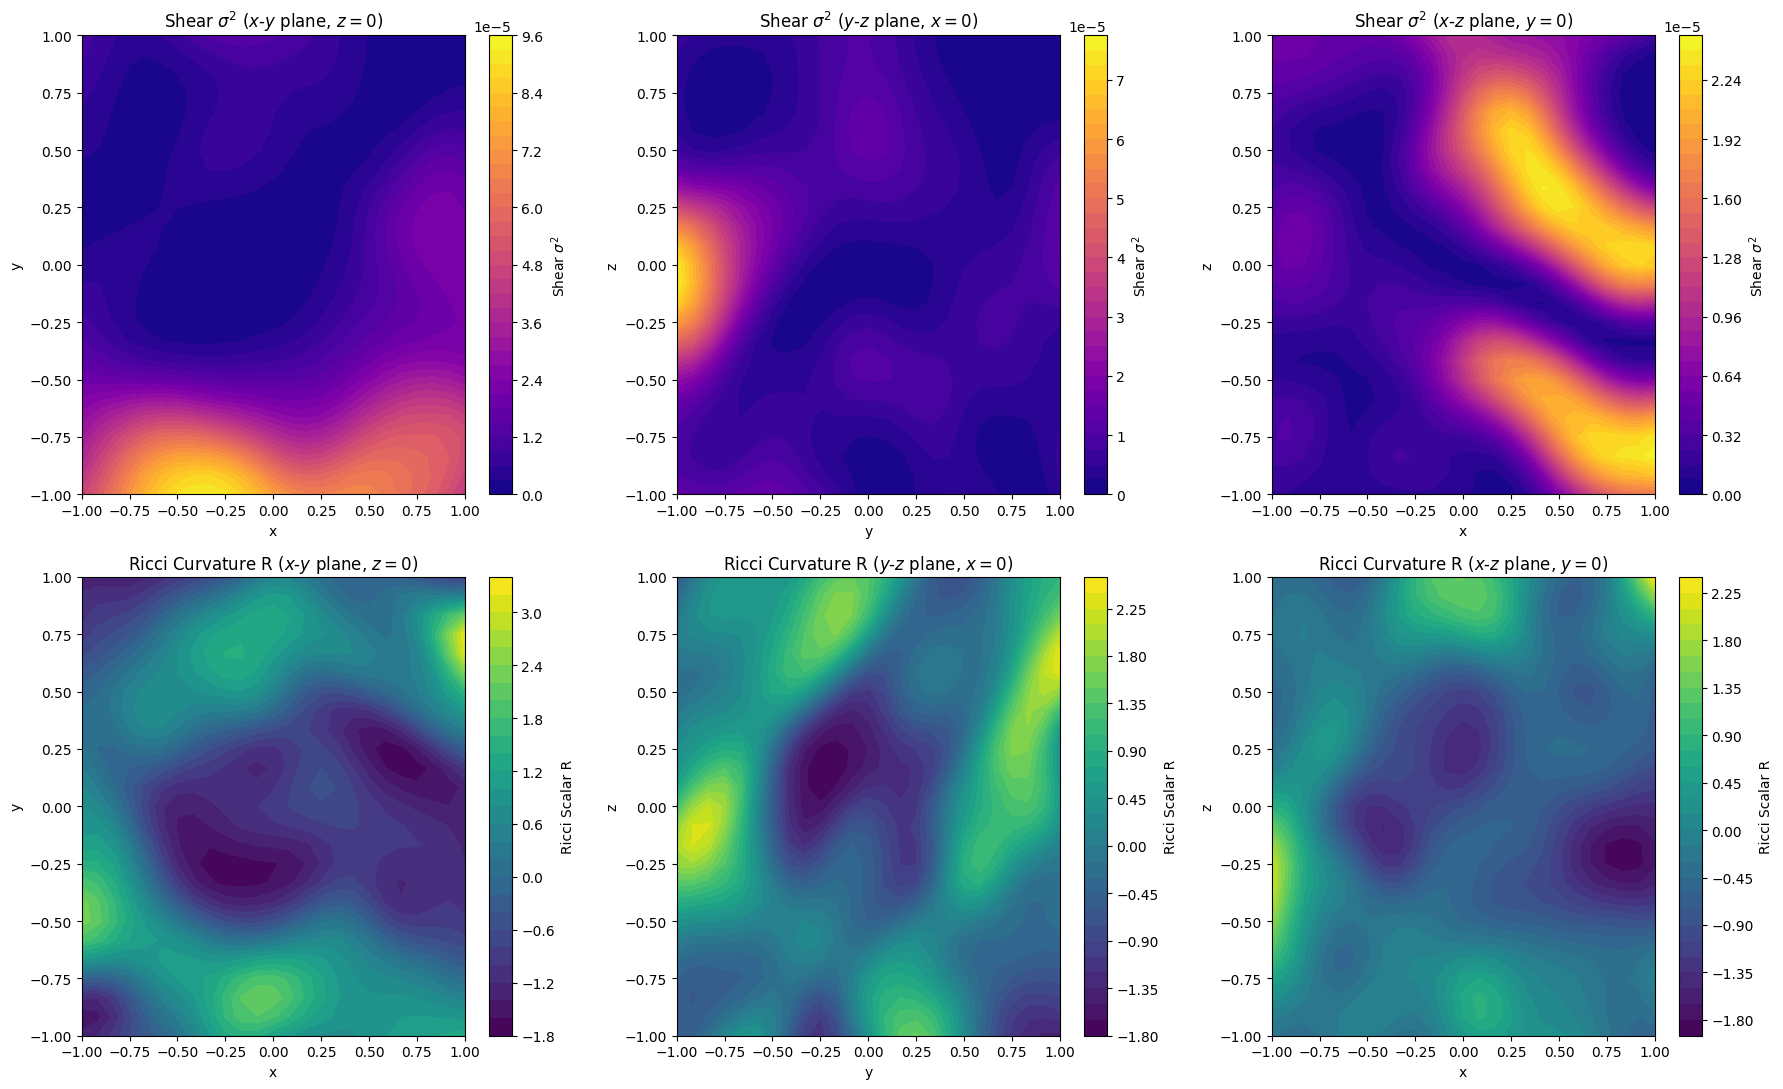

In [39]:
import numpy as np

from src.core.tensors import get_ricci_scalar

# Keep grid size moderate for fast CPU/GPU evaluation
grid_res = 25
grid_vals = np.linspace(-1.0, 1.0, grid_res)
U, V = np.meshgrid(grid_vals, grid_vals)

# Setup coordinate grids for the three planes at t=1.0 today
# 1. x-y plane (z = 0)
xy_coords = np.stack([np.ones_like(U) * 1.0, U, V, np.zeros_like(U)], axis=-1)
# 2. y-z plane (x = 0)
yz_coords = np.stack([np.ones_like(U) * 1.0, np.zeros_like(U), U, V], axis=-1)
# 3. x-z plane (y = 0)
xz_coords = np.stack([np.ones_like(U) * 1.0, U, np.zeros_like(U), V], axis=-1)

# Concatenate all points to run through vmap once
all_coords = np.concatenate([
    xy_coords.reshape(-1, 4),
    yz_coords.reshape(-1, 4),
    xz_coords.reshape(-1, 4)
], axis=0)

def evaluate_kinematics_2d(model, flat_coords):
    def compute_single(coords):
        g = model(coords)
        g_spatial = g[1:4, 1:4]
        g_spatial_inv = jnp.linalg.inv(g_spatial)
        
        dg_dt = jacfwd(model)(coords)[:, :, 0]
        dg_spatial_dt = dg_dt[1:4, 1:4]
        alpha = jnp.sqrt(-g[0, 0])
        
        theta_ij = (1.0 / (2.0 * alpha)) * dg_spatial_dt
        h_tensor = jnp.einsum('ik,kj->ij', g_spatial_inv, theta_ij)
        
        h_mean = jnp.trace(h_tensor) / 3.0
        sigma_tensor = h_tensor - h_mean * jnp.eye(3)
        sigma_sq = 0.5 * jnp.einsum('ij,ji->', sigma_tensor, sigma_tensor)
        
        ricci_R = get_ricci_scalar(model, coords)
        
        return sigma_sq, ricci_R
        
    return vmap(compute_single)(flat_coords)

# Evaluate all flat coordinates
sigma_flat, ricci_flat = evaluate_kinematics_2d(model, all_coords)

# Split results back into the three planes
n_points_per_plane = grid_res * grid_res
sigma_xy = sigma_flat[:n_points_per_plane].reshape(grid_res, grid_res)
sigma_yz = sigma_flat[n_points_per_plane:2*n_points_per_plane].reshape(
    grid_res, grid_res)
sigma_xz = sigma_flat[2*n_points_per_plane:].reshape(grid_res, grid_res)

ricci_xy = ricci_flat[:n_points_per_plane].reshape(grid_res, grid_res)
ricci_yz = ricci_flat[n_points_per_plane:2*n_points_per_plane].reshape(
    grid_res, grid_res)
ricci_xz = ricci_flat[2*n_points_per_plane:].reshape(grid_res, grid_res)

# Plot 2D contour maps (2x3 grid)
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# Row 0: Shear Scalar maps
c00 = axes[0, 0].contourf(U, V, sigma_xy, levels=30, cmap='plasma')
fig.colorbar(c00, ax=axes[0, 0], label=r'Shear $\sigma^2$')
axes[0, 0].set_xlabel('x')
axes[0, 0].set_ylabel('y')
axes[0, 0].set_title(r'Shear $\sigma^2$ ($x$-$y$ plane, $z=0$)')

c01 = axes[0, 1].contourf(U, V, sigma_yz, levels=30, cmap='plasma')
fig.colorbar(c01, ax=axes[0, 1], label=r'Shear $\sigma^2$')
axes[0, 1].set_xlabel('y')
axes[0, 1].set_ylabel('z')
axes[0, 1].set_title(r'Shear $\sigma^2$ ($y$-$z$ plane, $x=0$)')

c02 = axes[0, 2].contourf(U, V, sigma_xz, levels=30, cmap='plasma')
fig.colorbar(c02, ax=axes[0, 2], label=r'Shear $\sigma^2$')
axes[0, 2].set_xlabel('x')
axes[0, 2].set_ylabel('z')
axes[0, 2].set_title(r'Shear $\sigma^2$ ($x$-$z$ plane, $y=0$)')

# Row 1: Ricci Curvature maps
c10 = axes[1, 0].contourf(U, V, ricci_xy, levels=30, cmap='viridis')
fig.colorbar(c10, ax=axes[1, 0], label='Ricci Scalar R')
axes[1, 0].set_xlabel('x')
axes[1, 0].set_ylabel('y')
axes[1, 0].set_title('Ricci Curvature R ($x$-$y$ plane, $z=0$)')

c11 = axes[1, 1].contourf(U, V, ricci_yz, levels=30, cmap='viridis')
fig.colorbar(c11, ax=axes[1, 1], label='Ricci Scalar R')
axes[1, 1].set_xlabel('y')
axes[1, 1].set_ylabel('z')
axes[1, 1].set_title('Ricci Curvature R ($y$-$z$ plane, $x=0$)')

c12 = axes[1, 2].contourf(U, V, ricci_xz, levels=30, cmap='viridis')
fig.colorbar(c12, ax=axes[1, 2], label='Ricci Scalar R')
axes[1, 2].set_xlabel('x')
axes[1, 2].set_ylabel('z')
axes[1, 2].set_title('Ricci Curvature R ($x$-$z$ plane, $y=0$)')

plt.tight_layout()
plt.show()


## 3D Spacetime Visualizations

Here we visualize the Ricci curvature $R$ and Shear $\sigma^2$ geometries using 3D surface plots.

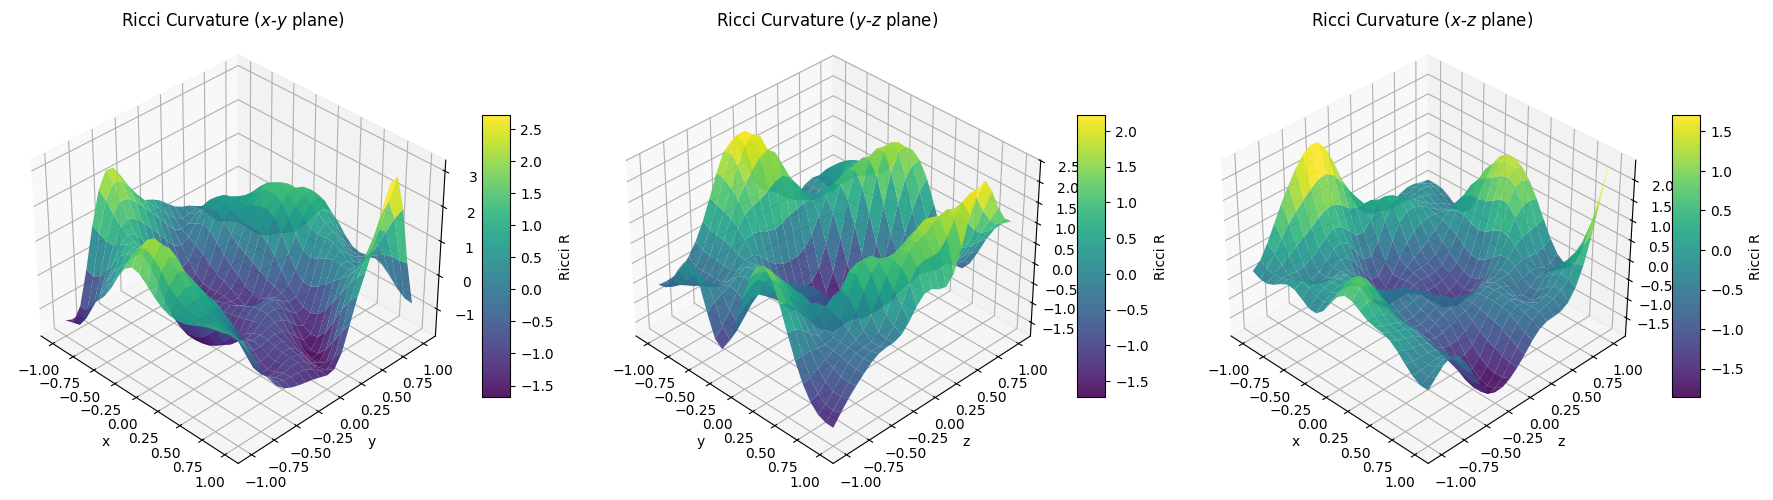

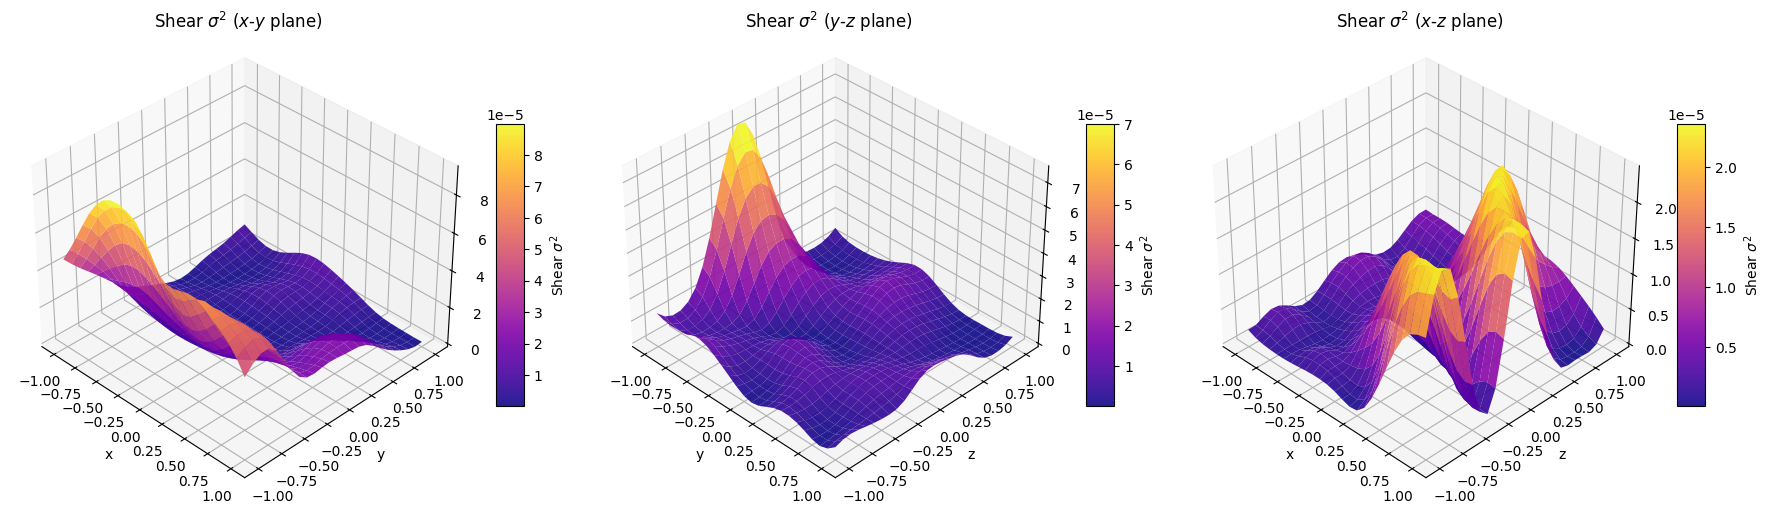

In [40]:
# 3D Landscapes and Wall Projections of Curvature and Shear
import matplotlib.pyplot as plt
import numpy as np

# Reuse U, V grids and ricci/shear slices from the previous cell
# Convert JAX arrays to numpy for 3D Matplotlib compatibility
ricci_xy_np = np.asarray(ricci_xy)
ricci_yz_np = np.asarray(ricci_yz)
ricci_xz_np = np.asarray(ricci_xz)
sigma_xy_np = np.asarray(sigma_xy)
sigma_yz_np = np.asarray(sigma_yz)
sigma_xz_np = np.asarray(sigma_xz)

# 1a. Ricci Curvature Landscapes (3D Height-Maps)
fig1a = plt.figure(figsize=(18, 5))

ax1 = fig1a.add_subplot(131, projection='3d')
surf1 = ax1.plot_surface(
    U, V, ricci_xy_np, cmap='viridis', edgecolor='none', alpha=0.9
)
fig1a.colorbar(
    surf1, ax=ax1, shrink=0.6, aspect=10, label='Ricci R'
)
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('Ricci R')
ax1.set_title('Ricci Curvature ($x$-$y$ plane)')
ax1.view_init(elev=35, azim=-45)

ax2 = fig1a.add_subplot(132, projection='3d')
surf2 = ax2.plot_surface(
    U, V, ricci_yz_np, cmap='viridis', edgecolor='none', alpha=0.9
)
fig1a.colorbar(
    surf2, ax=ax2, shrink=0.6, aspect=10, label='Ricci R'
)
ax2.set_xlabel('y')
ax2.set_ylabel('z')
ax2.set_zlabel('Ricci R')
ax2.set_title('Ricci Curvature ($y$-$z$ plane)')
ax2.view_init(elev=35, azim=-45)

ax3 = fig1a.add_subplot(133, projection='3d')
surf3 = ax3.plot_surface(
    U, V, ricci_xz_np, cmap='viridis', edgecolor='none', alpha=0.9
)
fig1a.colorbar(
    surf3, ax=ax3, shrink=0.6, aspect=10, label='Ricci R'
)
ax3.set_xlabel('x')
ax3.set_ylabel('z')
ax3.set_zlabel('Ricci R')
ax3.set_title('Ricci Curvature ($x$-$z$ plane)')
ax3.view_init(elev=35, azim=-45)

plt.tight_layout()
plt.show()

# 1b. Shear Scalar Landscapes (3D Height-Maps)
fig1b = plt.figure(figsize=(18, 5))

ax1_s = fig1b.add_subplot(131, projection='3d')
surf1_s = ax1_s.plot_surface(
    U, V, sigma_xy_np, cmap='plasma', edgecolor='none', alpha=0.9
)
fig1b.colorbar(
    surf1_s, ax=ax1_s, shrink=0.6, aspect=10, label=r'Shear $\sigma^2$'
)
ax1_s.set_xlabel('x')
ax1_s.set_ylabel('y')
ax1_s.set_zlabel(r'Shear $\sigma^2$')
ax1_s.set_title(r'Shear $\sigma^2$ ($x$-$y$ plane)')
ax1_s.view_init(elev=35, azim=-45)

ax2_s = fig1b.add_subplot(132, projection='3d')
surf2_s = ax2_s.plot_surface(
    U, V, sigma_yz_np, cmap='plasma', edgecolor='none', alpha=0.9
)
fig1b.colorbar(
    surf2_s, ax=ax2_s, shrink=0.6, aspect=10, label=r'Shear $\sigma^2$'
)
ax2_s.set_xlabel('y')
ax2_s.set_ylabel('z')
ax2_s.set_zlabel(r'Shear $\sigma^2$')
ax2_s.set_title(r'Shear $\sigma^2$ ($y$-$z$ plane)')
ax2_s.view_init(elev=35, azim=-45)

ax3_s = fig1b.add_subplot(133, projection='3d')
surf3_s = ax3_s.plot_surface(
    U, V, sigma_xz_np, cmap='plasma', edgecolor='none', alpha=0.9
)
fig1b.colorbar(
    surf3_s, ax=ax3_s, shrink=0.6, aspect=10, label=r'Shear $\sigma^2$'
)
ax3_s.set_xlabel('x')
ax3_s.set_ylabel('z')
ax3_s.set_zlabel(r'Shear $\sigma^2$')
ax3_s.set_title(r'Shear $\sigma^2$ ($x$-$z$ plane)')
ax3_s.view_init(elev=35, azim=-45)

plt.tight_layout()
plt.show()

## Plot 4D Spatial Weight maps

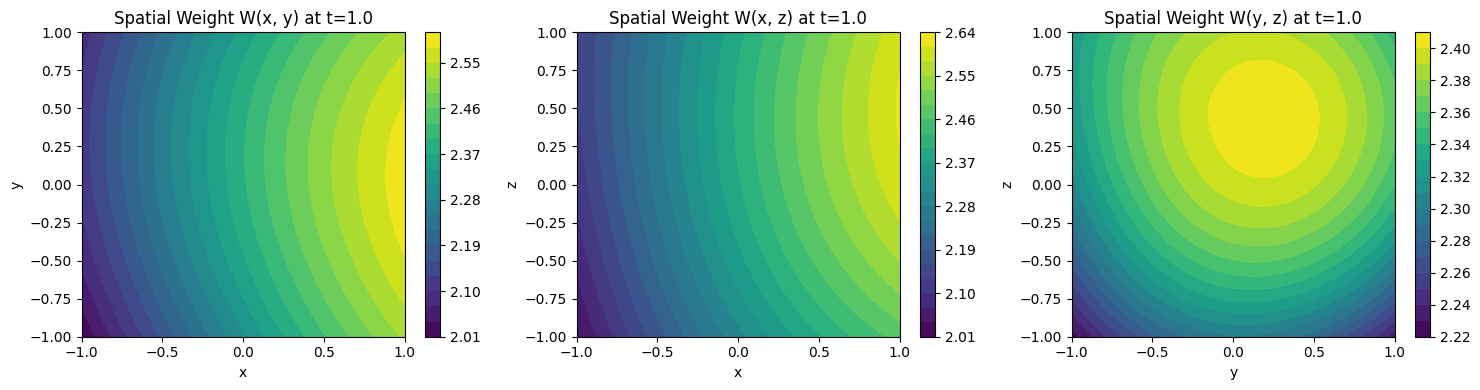

In [41]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

# We evaluate the spatial weights today (t=1.0) across the 3D volume
t_val = 1.0
grid_size = 30
lim = 1.0
x_grid = jnp.linspace(-lim, lim, grid_size)
y_grid = jnp.linspace(-lim, lim, grid_size)
z_grid = jnp.linspace(-lim, lim, grid_size)

# Create 2D slices
X_xy, Y_xy = jnp.meshgrid(x_grid, y_grid)
coords_xy = jnp.stack(
  [jnp.full_like(X_xy, t_val), X_xy, Y_xy, jnp.zeros_like(X_xy)], axis=-1
)

X_xz, Z_xz = jnp.meshgrid(x_grid, z_grid)
coords_xz = jnp.stack(
  [jnp.full_like(X_xz, t_val), X_xz, jnp.zeros_like(X_xz), Z_xz], axis=-1
)

Y_yz, Z_yz = jnp.meshgrid(y_grid, z_grid)
coords_yz = jnp.stack(
  [jnp.full_like(Y_yz, t_val), jnp.zeros_like(Y_yz), Y_yz, Z_yz], axis=-1
)

# Evaluate spatial weight network
# We use vmap twice because the input grid is 2D (grid_size x grid_size)
get_w = jax.vmap(jax.vmap(model.get_spatial_weight))
w_xy = get_w(coords_xy).squeeze()
w_xz = get_w(coords_xz).squeeze()
w_yz = get_w(coords_yz).squeeze()

fig, axs = plt.subplots(1, 3, figsize=(15, 4))

# Using viridis as it is perceptually uniform and colorblind friendly
c0 = axs[0].contourf(X_xy, Y_xy, w_xy, levels=20, cmap="viridis")
fig.colorbar(c0, ax=axs[0])
axs[0].set_title(f"Spatial Weight W(x, y) at t={t_val}")
axs[0].set_xlabel("x")
axs[0].set_ylabel("y")

c1 = axs[1].contourf(X_xz, Z_xz, w_xz, levels=20, cmap="viridis")
fig.colorbar(c1, ax=axs[1])
axs[1].set_title(f"Spatial Weight W(x, z) at t={t_val}")
axs[1].set_xlabel("x")
axs[1].set_ylabel("z")

c2 = axs[2].contourf(Y_yz, Z_yz, w_yz, levels=20, cmap="viridis")
fig.colorbar(c2, ax=axs[2])
axs[2].set_title(f"Spatial Weight W(y, z) at t={t_val}")
axs[2].set_xlabel("y")
axs[2].set_ylabel("z")

plt.tight_layout()
plt.show()